In [623]:
import os
from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [624]:
# !pip install PyComplexHeatmap fastcluster

In [625]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [626]:
import PyComplexHeatmap as pch

In [627]:
disease = 'prostate'

9551


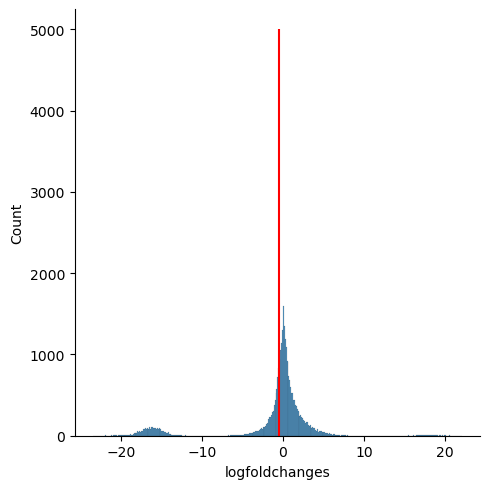

In [628]:
sc_degs = pd.read_csv(f'../data/single-cell/degs/{disease}.txt', sep='\t', index_col=0)
sc_degs

sc_lfc_cut = -.5
keep = sc_degs[sc_degs['logfoldchanges'] < sc_lfc_cut]
keep_genes = set(keep.index.to_list())
print(len(keep_genes))


sns.displot(sc_degs['logfoldchanges'])
plt.vlines(sc_lfc_cut, ymin=0, ymax=5000, colors='red', )

In [606]:
xenium_corrs = pd.read_csv(f'../data/spatial/regions/xenium/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
xenium_corrs

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RBP1,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB
case,,,,,,,,,,,,,,,,,,,,,
HT1011Z1,NaN,0.049869,NaN,-0.125221,NaN,0.099519,0.028548,0.033620,-0.034732,NaN,...,0.108179,0.101922,0.618606,0.189645,0.205680,-0.149385,-0.019232,-0.068472,0.017054,0.032711
HT814Z1,-0.044689,-0.012586,-0.017660,-0.006373,-0.000575,0.019478,-0.039153,0.009280,-0.012455,-0.024712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT817Z1,-0.032711,0.112135,-0.010937,-0.027948,-0.086949,0.167251,-0.158033,-0.054441,0.066803,-0.014623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT832Z1,0.069078,0.038412,-0.052498,0.037388,0.058757,0.206385,-0.032230,-0.014348,-0.027493,-0.023416,...,0.045534,0.065129,0.544033,0.130585,0.104574,-0.054124,0.083914,0.093728,0.185120,-0.017592
HT849Z1,-0.058295,-0.011940,0.038154,-0.015394,-0.110992,-0.007158,-0.078531,-0.057655,0.070107,0.030201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT852Z1,-0.045878,0.149456,-0.040740,-0.120997,-0.188174,0.000087,-0.206656,0.016290,0.058153,0.011674,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT891Z1,0.000111,0.084955,-0.012416,0.098127,0.064370,0.158622,-0.079379,0.061667,0.040324,0.160972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT913Z1,-0.034743,0.067391,0.046601,0.006120,-0.119926,0.100657,-0.078305,0.053864,0.017940,0.003903,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP003Z1,-0.031500,-0.004563,-0.002837,0.327822,0.170018,0.044462,-0.044508,-0.017189,-0.025407,-0.049501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [607]:

xenium_source = pd.read_csv(f'../data/spatial/regions/xenium/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
xenium_source.columns = [f'xenium_{c}' for c in xenium_source.columns]
xenium_source

,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count
ABCC11,0.002045,1,6,0.043478,0.260870,23
ACE2,0.039579,2,1,0.083333,0.041667,24
ACKR1,-0.001104,0,3,0.000000,0.130435,23
ACTA2,0.020443,2,7,0.083333,0.291667,24
ACTG2,0.008785,5,9,0.217391,0.391304,23
...,...,...,...,...,...,...
SETD7,-0.081546,0,3,0.000000,0.750000,4
TGFBI,0.020174,0,0,0.000000,0.000000,4
TIMP1,0.069078,1,1,0.250000,0.250000,4
TXNIP,0.064098,2,1,0.500000,0.250000,4


In [608]:
cosmx_corrs = pd.read_csv(f'../data/spatial/regions/cosmx/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
cosmx_corrs

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
case,,,,,,,,,,,,,,,,,,,,,
HT891Z1,-0.004345,0.004760,0.002333,-0.002800,0.006187,-0.004256,-0.010322,-0.002481,-0.002744,-0.008225,...,-0.008027,0.013393,0.008644,0.013113,0.015093,-0.001303,0.038196,0.002147,-0.019226,0.020817
HT913Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008981,NaN,NaN,...,-0.033852,-0.016124,-0.021404,-0.016866,-0.024688,-0.013975,-0.010224,-0.009128,-0.017402,-0.014900
HT935Z1,-0.017395,0.015109,0.003735,-0.011412,-0.001372,-0.008138,-0.002795,-0.013862,0.029932,-0.011156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT938Z1,-0.010216,-0.011255,-0.017756,-0.005889,-0.014603,0.015354,0.005204,0.008640,-0.008720,-0.014020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT997Z1,0.039033,0.011150,-0.002990,-0.019714,-0.003464,-0.007293,-0.023186,0.003050,0.006156,0.000038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP005Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104135,NaN,NaN,...,0.086442,-0.026369,0.027424,-0.003532,-0.053733,-0.033604,0.102497,-0.036121,-0.049125,0.129993
SP012Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020848,NaN,NaN,...,-0.023728,0.000450,-0.004325,0.001528,-0.018566,-0.040371,0.010255,-0.000640,0.035211,-0.009502


In [609]:
cosmx_source = pd.read_csv(f'../data/spatial/regions/cosmx/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
cosmx_source.columns = [f'cosmx_{c}' for c in cosmx_source.columns]
cosmx_source

,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,cosmx_negative_passed_threshold_fraction,cosmx_total_count
A1BG,0.001769,1,0,0.25,0.00,4
A2M,0.004941,0,0,0.00,0.00,4
AAAS,-0.003669,0,0,0.00,0.00,4
AAK1,-0.009954,0,1,0.00,0.25,4
AAMP,-0.003313,0,0,0.00,0.00,4
...,...,...,...,...,...,...
RPS4Y1,-0.022314,0,2,0.00,0.50,4
SAA1/2,0.035181,2,0,0.50,0.00,4
TPSAB1/B2,-0.010936,0,1,0.00,0.25,4
TPT1,-0.012636,1,2,0.25,0.50,4


In [610]:
visiumhd_corrs = pd.read_csv(f'../data/spatial/regions/visiumhd/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
visiumhd_corrs

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
case,,,,,,,,,,,,,,,,,,,,,
HT891Z1,-0.005054,-0.029080,-0.022610,0.034495,-0.049223,-0.046194,-0.058230,0.128590,-0.012251,-0.044498,...,-0.099740,-0.147907,-0.087422,-0.100594,-0.081806,-0.045061,-0.110991,0.016671,-0.035543,-0.090404
HT935Z1,-0.016434,0.001382,-0.014886,-0.011200,-0.006287,0.010028,-0.016146,0.027569,-0.003020,-0.010813,...,-0.000459,-0.004532,0.016279,0.011851,0.012742,-0.009095,0.012125,0.055445,0.018846,0.004047


In [611]:
visiumhd_source = pd.read_csv(f'../data/spatial/regions/visiumhd/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
visiumhd_source.columns = [f'visiumhd_{c}' for c in visiumhd_source.columns]
visiumhd_source


,visiumhd_basal_layer_correlation,visiumhd_positive_passed_threshold,visiumhd_negative_passed_threshold,visiumhd_positive_passed_threshold_fraction,visiumhd_negative_passed_threshold_fraction,visiumhd_total_count
SAMD11,-0.010744,0,0,0.0,0.0,2
NOC2L,-0.013849,0,0,0.0,0.0,2
KLHL17,-0.018748,0,0,0.0,0.0,2
PLEKHN1,0.011647,0,0,0.0,0.0,2
PERM1,-0.027755,0,1,0.0,0.5,2
...,...,...,...,...,...,...
MT-ND4L,-0.027078,0,1,0.0,0.5,2
MT-ND4,-0.049433,0,1,0.0,0.5,2
MT-ND5,0.036058,1,0,0.5,0.0,2
MT-ND6,-0.008349,0,0,0.0,0.0,2


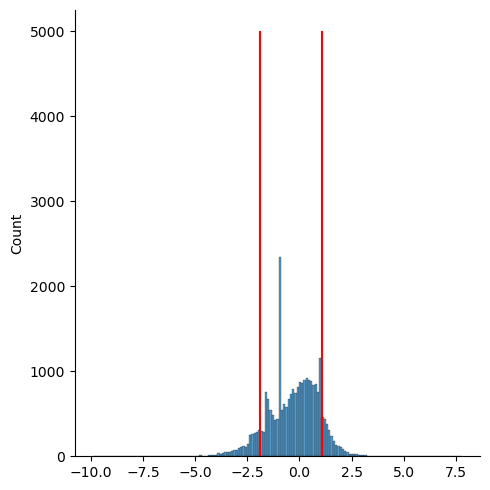

In [612]:
visium_source = pd.read_csv(f'../data/spatial/regions/visium/ttest_stat_caselevel_{disease}.txt', sep='\t', index_col=0)

arr = visium_source.values.flatten()
arr = arr[~pd.isnull(arr)]
lower, upper = np.percentile(arr, [10, 90])
xs = arr[arr>-10]
sns.displot(xs)
plt.vlines([lower, upper], ymin=0, ymax=5000, colors=['red', 'red'], )


In [613]:
visium_metrics = pd.DataFrame(visium_source.mean(0))
visium_metrics.columns = ['ttest_stat']
visium_metrics['total_count'] = (~pd.isnull(visium_source)).sum(0)
visium_metrics['positive_passed_threshold'] = (visium_source > upper).sum(0)
visium_metrics['negative_passed_threshold'] = (visium_source < lower).sum(0)
visium_metrics.columns = [f'visium_{c}' for c in visium_metrics.columns]
visium_metrics
# stat_df.to_csv(output_dir / 'ttest_stat_caselevel_prostate.txt', sep='\t')


,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold
SAMD11,-0.367332,2,0,0
NOC2L,-1.198571,2,0,0
KLHL17,0.944240,1,0,0
PLEKHN1,-0.221052,2,0,0
PERM1,NaN,0,0,0
...,...,...,...,...
KRTAP3-1,NaN,0,0,0
KRTAP10-6,NaN,0,0,0
KRTAP12-4,NaN,0,0,0
BMP15,NaN,0,0,0


In [614]:
to_values = {
    'xenium': xenium_corrs,
    'cosmx': cosmx_corrs,
    'visium': visium_source,
    'visiumhd': visiumhd_corrs
}

In [615]:
combined_source = pd.merge(xenium_source, cosmx_source, left_index=True, right_index=True, how='outer')
combined_source = pd.merge(combined_source, visiumhd_source, left_index=True, right_index=True, how='outer')
combined_source = pd.merge(combined_source, visium_metrics, left_index=True, right_index=True, how='outer')

for c in combined_source.columns:
    if 'total_count' in c or 'passed_threshold' in c:
        combined_source[c] = [0 if pd.isnull(x) else x for x in combined_source[c]]

combined_source

,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,...,visiumhd_basal_layer_correlation,visiumhd_positive_passed_threshold,visiumhd_negative_passed_threshold,visiumhd_positive_passed_threshold_fraction,visiumhd_negative_passed_threshold_fraction,visiumhd_total_count,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold
A1BG,NaN,0.0,0.0,0.0,0.0,0.0,0.001769,1.0,0.0,0.25,...,NaN,0.0,0.0,0.0,0.0,0.0,-1.000000,2.0,0.0,0.0
A1BG-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
A1CF,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,-0.031298,0.0,0.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0
A2M,NaN,0.0,0.0,0.0,0.0,0.0,0.004941,0.0,0.0,0.00,...,0.051901,1.0,0.0,0.5,0.0,2.0,0.878449,2.0,1.0,0.0
A2M-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11B,0.022715,0.0,0.0,0.0,0.0,5.0,-0.002277,0.0,0.0,0.00,...,0.003765,0.0,0.0,0.0,0.0,2.0,-0.354825,2.0,0.0,0.0
ZYX,0.169991,4.0,0.0,0.8,0.0,5.0,0.002115,1.0,0.0,0.25,...,0.024007,0.0,0.0,0.0,0.0,2.0,0.469453,2.0,1.0,0.0
ZZEF1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,0.012181,0.0,0.0,0.0,0.0,2.0,0.638006,2.0,1.0,0.0
ZZZ3,NaN,0.0,0.0,0.0,0.0,0.0,0.006297,1.0,0.0,0.25,...,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0


In [616]:
dtypes = ['xenium', 'cosmx', 'visium', 'visiumhd']

combined_source['total_count'] = np.stack([combined_source[f'{dtype}_total_count'].values for dtype in dtypes]).sum(0)
combined_source['positive_passed_threshold'] = np.stack([combined_source[f'{dtype}_positive_passed_threshold'].values for dtype in dtypes]).sum(0)
combined_source['negative_passed_threshold'] = np.stack([combined_source[f'{dtype}_negative_passed_threshold'].values for dtype in dtypes]).sum(0)

combined_source['positive_passed_threshold_fraction'] = combined_source['positive_passed_threshold'] / combined_source['total_count']
combined_source['negative_passed_threshold_fraction'] = combined_source['negative_passed_threshold'] / combined_source['total_count']

f = combined_source[[f'{dtype}_ttest_stat' if dtype == 'visium' else f'{dtype}_basal_layer_correlation' for dtype in ['visium', 'visiumhd', 'xenium']]]
combined_source['present_count'] = np.sum(~pd.isnull(f), 1)


combined_source




,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,...,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold,total_count,positive_passed_threshold,negative_passed_threshold,positive_passed_threshold_fraction,negative_passed_threshold_fraction,present_count
A1BG,NaN,0.0,0.0,0.0,0.0,0.0,0.001769,1.0,0.0,0.25,...,-1.000000,2.0,0.0,0.0,6.0,1.0,0.0,0.166667,0.0,1
A1BG-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
A1CF,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,1
A2M,NaN,0.0,0.0,0.0,0.0,0.0,0.004941,0.0,0.0,0.00,...,0.878449,2.0,1.0,0.0,8.0,2.0,0.0,0.250000,0.0,2
A2M-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11B,0.022715,0.0,0.0,0.0,0.0,5.0,-0.002277,0.0,0.0,0.00,...,-0.354825,2.0,0.0,0.0,13.0,0.0,0.0,0.000000,0.0,3
ZYX,0.169991,4.0,0.0,0.8,0.0,5.0,0.002115,1.0,0.0,0.25,...,0.469453,2.0,1.0,0.0,13.0,6.0,0.0,0.461538,0.0,3
ZZEF1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,0.638006,2.0,1.0,0.0,4.0,1.0,0.0,0.250000,0.0,2
ZZZ3,NaN,0.0,0.0,0.0,0.0,0.0,0.006297,1.0,0.0,0.25,...,NaN,0.0,0.0,0.0,4.0,1.0,0.0,0.250000,0.0,0


In [617]:
output_dir = Path('../data/spatial/plots')
output_dir.mkdir(parents=True, exist_ok=True)

combined_source.index.name = 'feature_name'
combined_source.to_csv(output_dir / f'gene_statistics_{disease}.txt', sep='\t')

In [618]:
# comparison_type = 'positive'
comparison_type = 'negative'


In [593]:
# identifier = 'fraction'

# source = combined_source.copy()
# source = source.loc[[g for g in keep_genes if g in source.index]]
# source = source[source['present_count']>=2]
# source = source.sort_values(f'{comparison_type}_passed_threshold_fraction', ascending=False)
# source = source.iloc[:50]

In [594]:
# identifier = 'coverage'

# source = combined_source.copy()
# source = source.loc[[g for g in keep_genes if g in source.index]]
# source = source.sort_values(f'{comparison_type}_passed_threshold', ascending=False)
# source = source.iloc[:50]

In [619]:
identifier = 'value'

source = combined_source.copy()
source = source.loc[[g for g in keep_genes if g in source.index]]
source = source[source['present_count']>=2]


value_df = source[['xenium_basal_layer_correlation', 'visiumhd_basal_layer_correlation', 'visium_ttest_stat']]
value_df /= value_df.std(0)
source['score'] = value_df.mean(1)
source = source.sort_values(f'score', ascending=False if comparison_type == 'positive' else True)
source = source.iloc[:50]

In [596]:
# identifier = 'interesting'

# of_interest = [
#     'PLAT',
#     'NTN4',
#     'SOX9',
#     'FAS',
#     'MGP',
#     'FLRT3',
#     'DUOXA1',
#     'HMGCS2',
#     'UPK1A',
#     'TFF1',
#     'SERPINA3',
#     'CPLX3',
#     'TCIM',
#     'SORL1',
#     'CP',
#     'CAMK2N1',
#     'GFRA1',
#     'FASN',
#     'EPHA6',
#     'MKI67',
#     'MYC',
#     'GDF15',
#     'CEACAM20',
#     'ANPEP',
#     'ALDH1A3',
#     'KRT8',
#     'GLUL',
#     'VEGFA',
#     'LGALS1',
#     'SLC40A1',
#     'LMAN1L',
#     'FHL2',
#     'CD44'
# ]

# source = combined_source.copy()
# source = source.loc[[g for g in keep_genes if g in source.index]]
# source = source.loc[[g for g in of_interest if g in source.index]]
# source

In [598]:

to_source = {}
for dtype in dtypes:
    src = source.copy()
    src['passed'] = src[f'{dtype}_{comparison_type}_passed_threshold']
    src['failed'] = src[f'{dtype}_total_count'] - src[f'{dtype}_{comparison_type}_passed_threshold']
    src['metric'] = 'ttest stat' if dtype == 'visium' else 'basal layer correlation'
    src['gene'] = src.index.to_list()
    
    to_source[dtype] = src

In [599]:
def plot_annotated_hm(source, value_col, vmax=1, vmin=-1, cmap='bwr'):
    if vmax is None:
        vmax = source[value_col].max()
    if vmin is None:
        vmin = source[value_col].min() 
    
    col_ha = pch.HeatmapAnnotation(
        count=pch.anno_barplot(source[['passed', 'failed']], legend=True, cmap='Dark2', ylim=(0, source[['passed', 'failed']].values.sum(1).max())),
#         values=pch.anno_boxplot(df_box, colors='#1368bd',height=15),
        plot=True,
        legend=True,
        legend_gap=5,
        hgap=0.5,
        show_colnames=False,
    )
#     col_ha.show_ticklabels(source.index.tolist(),fontdict={'color':'black'},rotation=-90)

    plt.figure(figsize=(15, 2))
    cm = pch.DotClustermapPlotter(
        source,
        x='gene',
        y='metric',
        value=value_col,
        c=value_col,
        cmap=cmap,
        vmax=vmax,
        vmin=vmin,
        row_cluster=False,
        col_cluster=False,
        show_colnames=True,
        top_annotation=col_ha,
        linewidth=1.,
        edgecolor='#555555',
        x_order = source['gene']
    )
    return cm

Starting plotting HeatmapAnnotations
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 276.46966616021575
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 16.758333333333333 mm


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:409: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["c"] = data.pivot_table(


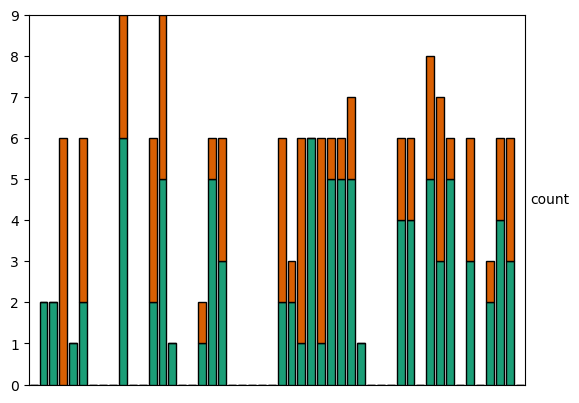

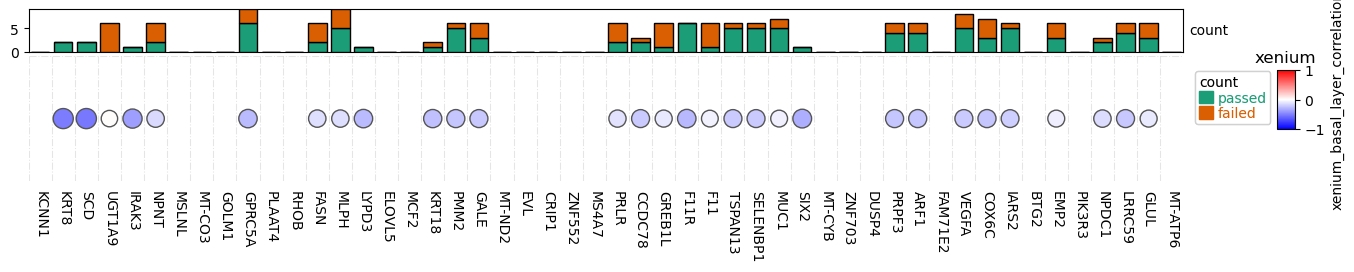

In [600]:
dtype = 'xenium'
cm = plot_annotated_hm(to_source[dtype], f'{dtype}_basal_layer_correlation')
plt.title(dtype)
plt.savefig(output_dir / f'heatmap_{identifier}_{comparison_type}_{dtype}_{disease}.svg')
plt.show()

Starting plotting HeatmapAnnotations
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 276.46966616021575
Starting plotting HeatmapAnnotations


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:409: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["c"] = data.pivot_table(


Plotting legends..
Estimated legend width: 16.758333333333333 mm


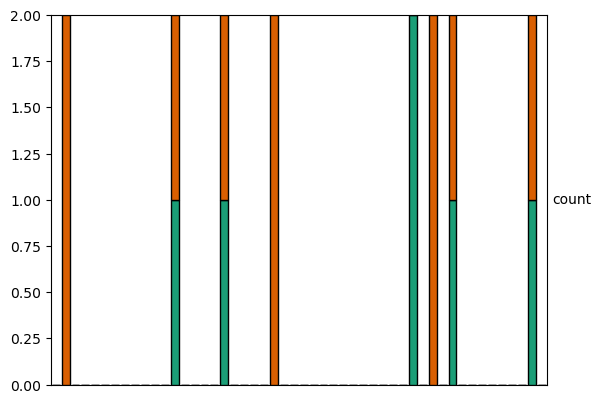

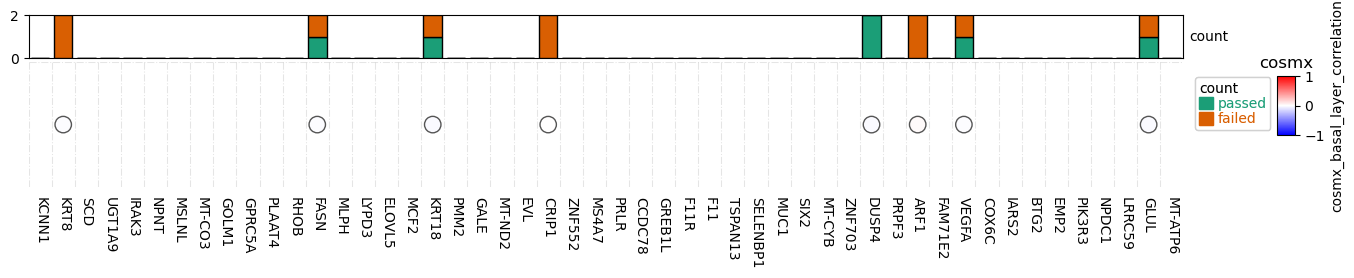

In [601]:
dtype = 'cosmx'
plot_annotated_hm(to_source[dtype], f'{dtype}_basal_layer_correlation')
plt.title(dtype)
plt.savefig(output_dir / f'heatmap_{identifier}_{comparison_type}_{dtype}_{disease}.svg')

Starting plotting HeatmapAnnotations
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 276.46966616021575
Starting plotting HeatmapAnnotations


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:409: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["c"] = data.pivot_table(


Plotting legends..
Estimated legend width: 16.758333333333333 mm


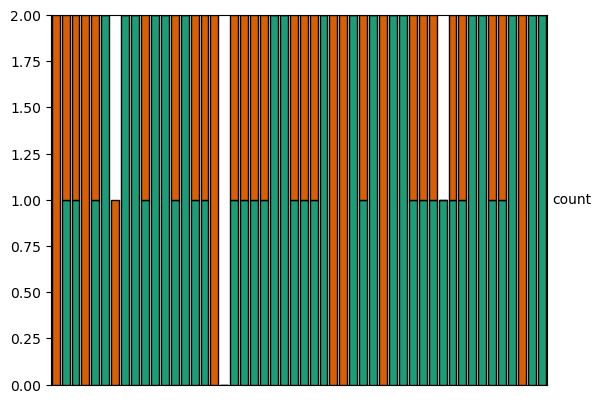

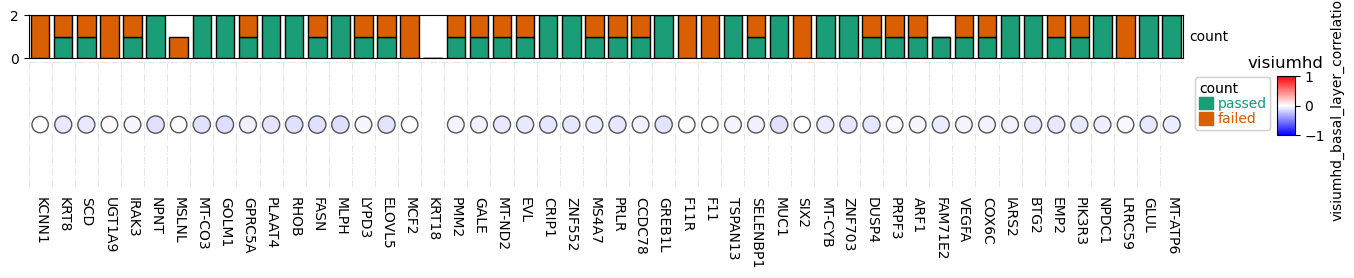

In [602]:
dtype = 'visiumhd'
plot_annotated_hm(to_source[dtype], f'{dtype}_basal_layer_correlation')
plt.title(dtype)
plt.savefig(output_dir / f'heatmap_{identifier}_{comparison_type}_{dtype}_{disease}.svg')

Starting plotting HeatmapAnnotations
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 276.46966616021575
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 16.758333333333333 mm


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:409: FutureWarning: The provided callable <function mean at 0x7f6b081a2660> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["c"] = data.pivot_table(


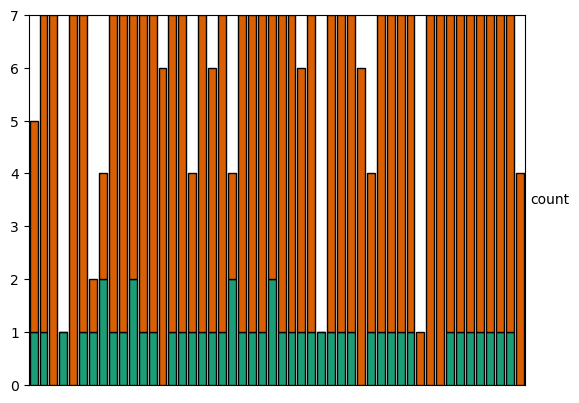

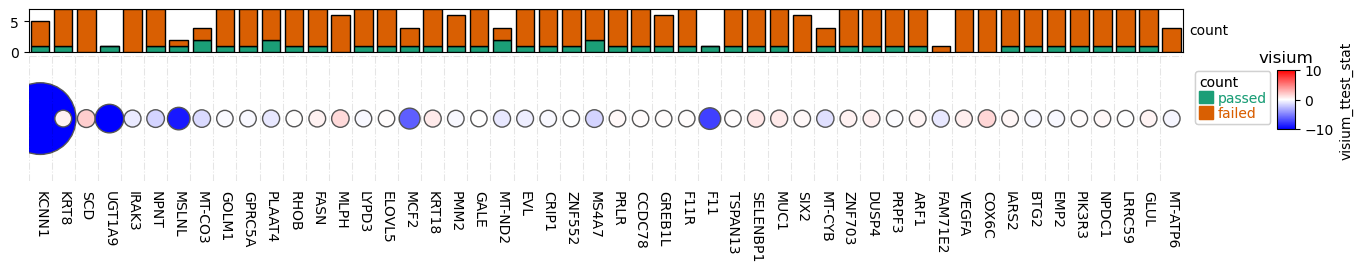

In [603]:
dtype = 'visium'
vmin, vmax = to_source[dtype][f'{dtype}_ttest_stat'].min(), to_source[dtype][f'{dtype}_ttest_stat'].max()
edge = np.max(np.abs([vmin, vmax]))
plot_annotated_hm(to_source[dtype], f'{dtype}_ttest_stat',
                  vmax=min(edge, 10),
                  vmin=-min(edge, 10), cmap='bwr')
plt.title(dtype)
plt.savefig(output_dir / f'heatmap_{identifier}_{comparison_type}_{dtype}_{disease}.svg')



In [381]:
df = pd.read_csv('../data/spatial/metadata/2d_data_tracking_metadata.csv', sep=',')
df

,case,sid,is_tnbc,tissue,platform,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,SP003Z1,SP003Z1-Fp1Us1_1,False,prostate,xenium,NaN,NaN,NaN
1,SP017Z1,SP017Z1-Fp1B27Us1_17,False,prostate,xenium,NaN,NaN,NaN
2,SP017Z1,SP017Z1-Fp1B27Us1_2,False,prostate,xenium,NaN,NaN,NaN
3,SP017Z1,SP017Z1-Fp1B27Us1_24,False,prostate,xenium,NaN,NaN,NaN
4,SP017Z1,SP017Z1-Fp1B27Us1_9,False,prostate,xenium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
297,SP006Z1,SP006Z1-C8-U24,NaN,prostate,codex,NaN,NaN,NaN
298,SP017Z1,SP017Z1-U3,NaN,prostate,codex,NaN,NaN,NaN
299,SP017Z1,SP017Z1-U10,NaN,prostate,codex,NaN,NaN,NaN
300,SP017Z1,SP017Z1-U18,NaN,prostate,codex,NaN,NaN,NaN


In [382]:
grouped = df.groupby(['case', 'platform']).count()
grouped = grouped.reset_index()
grouped

,case,platform,sid,is_tnbc,tissue,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1581620AU1,xenium,1,1,1,0,0,0
1,1607059U1,xenium,1,1,1,0,0,0
2,1654977AU1,xenium,1,1,1,0,0,0
3,1661918aU1,xenium,1,1,1,0,0,0
4,HT1011Z1,xenium,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...
69,SP017Z1,he,3,0,3,0,0,0
70,SP017Z1,xenium,4,4,4,0,0,0
71,SP048Z1,xenium,2,2,2,0,0,0
72,SP050Z1,xenium,1,1,1,0,0,0


In [383]:
for dtype in set(grouped['platform']):
    f = grouped[grouped['platform']==dtype]
    print(dtype, f.shape)


xenium (33, 8)
visiumhd (4, 8)
he (7, 8)
codex (9, 8)
visium (12, 8)
cosmx (9, 8)


In [384]:
grouped = df.groupby(['sid', 'platform']).count()
grouped = grouped.reset_index()

for dtype in set(grouped['platform']):
    f = grouped[grouped['platform']==dtype]
    print(dtype, f.shape)


xenium (75, 8)
visiumhd (7, 8)
he (110, 8)
visium (28, 8)
codex (66, 8)
cosmx (16, 8)


In [385]:
grouped = df.groupby(['case', 'tissue']).count()
grouped = grouped.reset_index()
for x in set(df['tissue']):
    print(x, grouped[grouped['tissue']==x].shape)

prostate (30, 8)
breast (19, 8)


In [386]:
grouped

,case,tissue,sid,is_tnbc,platform,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1581620AU1,breast,1,1,1,0,0,0
1,1607059U1,breast,1,1,1,0,0,0
2,1654977AU1,breast,1,1,1,0,0,0
3,1661918aU1,breast,1,1,1,0,0,0
4,HT1011Z1,prostate,1,1,1,0,0,0
5,HT206B1,breast,21,7,21,0,0,0
6,HT297B1,breast,1,0,1,0,0,0
7,HT308B1,breast,3,0,3,0,0,0
8,HT323B1,breast,1,0,1,0,0,0
9,HT339B1,breast,2,0,2,0,0,0


In [387]:
grouped = df.groupby(['sid', 'tissue']).count()
grouped = grouped.reset_index()
for x in set(df['tissue']):
    print(x, grouped[grouped['tissue']==x].shape)

prostate (198, 8)
breast (103, 8)


In [388]:
len(set(df['case']))

49

,case,platform,sid,is_tnbc,tissue
0,1581620AU1,xenium,1,1,1
1,1607059U1,xenium,1,1,1
2,1654977AU1,xenium,1,1,1
3,1661918aU1,xenium,1,1,1
4,HT1011Z1,xenium,1,1,1
...,...,...,...,...,...
69,SP017Z1,he,3,0,3
70,SP017Z1,xenium,4,4,4
71,SP048Z1,xenium,2,2,2
72,SP050Z1,xenium,1,1,1


In [167]:
of_interest = [
    'PLAT',
    'NTN4',
    'SOX9',
    'FAS',
    'MGP',
    'FLRT3',
    'DUOXA1',
    'HMGCS2',
    'UPK1A',
    'TFF1',
    'SERPINA3',
    'CPLX3',
    'TCIM',
    'SORL1',
    'CP',
    'CAMK2N1',
    'GFRA1',
    'FASN',
    'EPHA6',
    'MKI67',
    'MYC',
    'GDF15',
    'CEACAM20',
    'ANPEP',
    'ALDH1A3',
    'KRT8',
    'GLUL',
    'VEGFA',
    'LGALS1',
    'SLC40A1',
    'LMAN1L',
    'FHL2',
    'CD44'
]

In [135]:
source = combined_source.copy()
source = source.loc[[g for g in keep_genes if g in source.index]]
source = source.loc[[g for g in of_interest if g in source.index]]
source

,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,...,visiumhd_total_count,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold,total_count,positive_passed_threshold,negative_passed_threshold,positive_passed_threshold_fraction,negative_passed_threshold_fraction
feature_name,,,,,,,,,,,,,,,,,,,,,
MGP,0.585599,1.0,0.0,1.000000,0.000000,1.0,0.048549,2.0,0.0,1.0,...,2.0,2.994773,7.0,3.0,1.0,12.0,8.0,1.0,0.666667,0.083333
FLRT3,-0.065624,0.0,1.0,0.000000,0.166667,6.0,NaN,0.0,0.0,0.0,...,2.0,0.428453,6.0,0.0,0.0,14.0,0.0,1.0,0.000000,0.071429
HMGCS2,0.136898,1.0,0.0,0.333333,0.000000,3.0,NaN,0.0,0.0,0.0,...,2.0,1.588812,6.0,3.0,0.0,11.0,4.0,1.0,0.363636,0.090909
UPK1A,-0.031450,0.0,1.0,0.000000,0.166667,6.0,NaN,0.0,0.0,0.0,...,2.0,0.541229,4.0,1.0,1.0,12.0,2.0,2.0,0.166667,0.166667
TFF1,0.070555,3.0,1.0,0.375000,0.125000,8.0,NaN,0.0,0.0,0.0,...,2.0,3.588245,6.0,4.0,0.0,16.0,8.0,2.0,0.500000,0.125000
TCIM,-0.074507,2.0,3.0,0.222222,0.333333,9.0,NaN,0.0,0.0,0.0,...,2.0,-0.827103,7.0,0.0,1.0,18.0,2.0,5.0,0.111111,0.277778
SORL1,0.028727,0.0,0.0,0.000000,0.000000,6.0,NaN,0.0,0.0,0.0,...,2.0,-0.325401,7.0,1.0,1.0,15.0,1.0,2.0,0.066667,0.133333
CAMK2N1,NaN,0.0,0.0,0.000000,0.000000,0.0,NaN,0.0,0.0,0.0,...,2.0,0.914908,7.0,1.0,1.0,9.0,1.0,1.0,0.111111,0.111111
GFRA1,NaN,0.0,0.0,0.000000,0.000000,0.0,NaN,0.0,0.0,0.0,...,2.0,1.222698,6.0,1.0,0.0,8.0,1.0,1.0,0.125000,0.125000


Starting plotting HeatmapAnnotations
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 485.765580143593
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 16.758333333333333 mm


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:409: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["c"] = data.pivot_table(


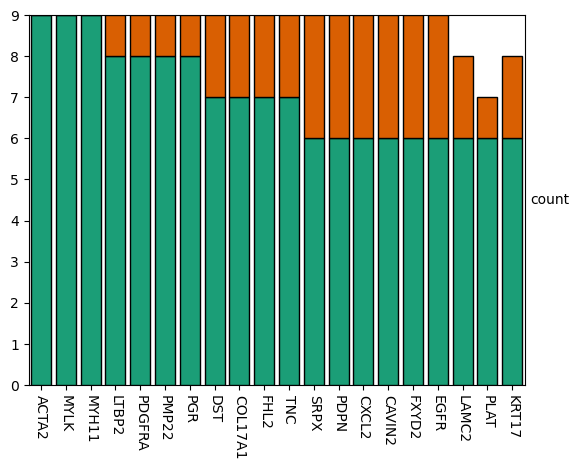

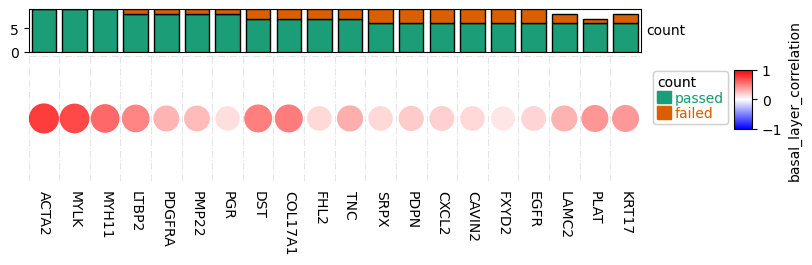

In [114]:

col_ha = pch.HeatmapAnnotation(
    count=pch.anno_barplot(source[['passed', 'failed']], legend=True, cmap='Dark2', ylim=(0, source[['passed', 'failed']].values.sum(1).max())),
    plot=True,
    legend=True,
    legend_gap=5,
    hgap=0.5
)
col_ha.show_ticklabels(source.index.tolist(),fontdict={'color':'black'},rotation=-90)

plt.figure(figsize=(8, 2))
cm = pch.DotClustermapPlotter(
    source,
    x='gene',
    y='metric',
    value='basal_layer_correlation',
    c='basal_layer_correlation',
    cmap='bwr',
    vmax=1,
    vmin=-1,
    row_cluster=False,
    col_cluster=False,
    show_colnames=True,
    top_annotation=col_ha,
    x_order = source['gene']
)

In [65]:
df_heatmap

,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9,sample10
Fea1,1.021189,1.767529,0.434141,-0.379495,0.021304,0.103287,0.042549,-0.036106,1.368995,2.147590
Fea2,-0.182383,2.018763,NaN,-0.208562,0.013580,-1.494592,-0.256997,0.310836,-0.811622,1.319464
Fea3,1.792945,0.441226,0.250563,1.141482,-0.966168,-2.746439,1.571032,0.942477,-0.412032,-0.368995
Fea4,0.369241,0.399599,0.993404,1.326220,0.460068,0.237590,-1.113887,0.265144,-1.077124,0.621418
Fea5,0.542055,-0.977246,1.613530,0.688094,0.127523,0.930185,-0.117169,-0.942768,-0.218707,0.765211
Fea6,0.371175,-1.269911,-0.994575,1.999141,-0.794467,0.019309,0.265772,-0.148963,0.359233,0.318121
Fea7,-0.327394,-0.383970,0.203793,-0.504397,-0.316371,-0.735560,-0.488276,-0.025591,-1.157445,-0.920224
Fea8,0.374612,0.151383,-0.711091,-1.293859,-0.236084,1.222421,-0.937272,1.388514,-1.000528,-1.965166
Fea9,-0.443887,1.527723,0.377996,-0.823383,1.038366,-0.290103,0.426704,0.447884,0.018712,1.336988
Fea10,-1.091622,1.067119,-0.390711,0.441904,-1.724821,-0.533024,1.207799,-0.834608,-0.460797,-0.449219


In [52]:
to_df_box['xenium'].T

,1581620A,1607059,1654977A,1661918a,HT206B1,HT591B1,HT704B1,HT727B1,HT944B1
gene,,,,,,,,,
PGR,0.117723,0.153737,0.224043,0.235988,0.427431,0.209652,-0.697748,0.305513,0.216192
SLC39A6,-0.108043,0.040560,0.505853,0.390000,0.584107,NaN,NaN,0.194873,0.247835
WNT4,-0.063843,0.324400,0.279281,0.161407,NaN,NaN,NaN,-0.086018,0.242679
PPP1R1B,-0.084285,-0.125971,-0.102771,-0.130987,0.393583,0.290669,0.429265,0.217153,-0.223687
TNFSF10,-0.049083,0.313970,-0.104904,-0.050172,NaN,NaN,NaN,0.327027,0.271265
CXCL2,0.019117,-0.119920,0.235644,-0.187238,0.273573,0.254785,0.296340,0.596530,0.275035
TFF1,-0.087164,0.088746,0.378536,0.229465,0.274621,NaN,0.012209,-0.186184,-0.145791
MGP,NaN,NaN,NaN,NaN,0.585599,NaN,NaN,NaN,NaN
CCL28,-0.077990,-0.168615,0.217305,-0.094172,NaN,NaN,NaN,0.622110,0.209409


In [51]:
df_box

,Gene1,Gene2,Gene3,Gene4
sample1,0.286769,2.645404,-0.528352,1.948076
sample2,1.917454,0.184080,-0.310687,1.221200
sample3,2.086001,-0.775531,-0.556691,0.789885
sample4,-0.781433,0.790010,-0.431243,-0.062932
sample5,0.387022,-0.648005,1.768118,1.006772
sample6,-1.476119,-0.319160,0.152812,0.884665
sample7,-0.039786,0.036311,-0.040052,-1.335061
sample8,0.653769,0.114357,-1.124977,-3.087648
sample9,2.408074,-1.975602,-1.052147,-0.604013
sample10,-0.822374,1.320188,-0.110645,0.617463


In [53]:
df.AB

sample1      AAAA1
sample2      AAAA1
sample3      AAAA1
sample4      AAAA1
sample5      AAAA1
sample6     BBBBB2
sample7     BBBBB2
sample8     BBBBB2
sample9     BBBBB2
sample10    BBBBB2
Name: AB, dtype: object

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm


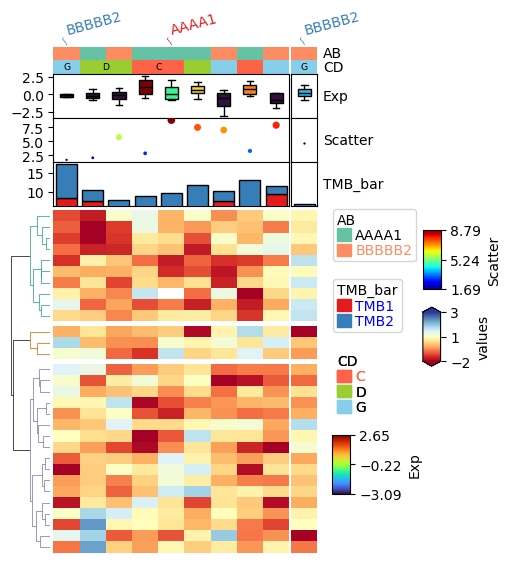

In [50]:
#Generate example dataset (random)
df = pd.DataFrame(['AAAA1'] * 5 + ['BBBBB2'] * 5, columns=['AB'])
df['CD'] = ['C'] * 3 + ['D'] * 3 + ['G'] * 4
df['EF'] = ['E'] * 6 + ['F'] * 2 + ['H'] * 2
df['F'] = np.random.normal(0, 1, 10)
df.index = ['sample' + str(i) for i in range(1, df.shape[0] + 1)]
df_box = pd.DataFrame(np.random.randn(10, 4), columns=['Gene' + str(i) for i in range(1, 5)])
df_box.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['TMB1', 'TMB2'])
df_bar.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_scatter = pd.DataFrame(np.random.uniform(0, 10, 10), columns=['Scatter'])
df_scatter.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_heatmap = pd.DataFrame(np.random.randn(30, 10), columns=['sample' + str(i) for i in range(1, 11)])
df_heatmap.index = ["Fea" + str(i) for i in range(1, df_heatmap.shape[0] + 1)]
df_heatmap.iloc[1, 2] = np.nan

plt.figure(figsize=(4, 6))
col_ha = pch.HeatmapAnnotation(label=pch.anno_label(df.AB, merge=True,rotation=15),
                           AB=pch.anno_simple(df.AB,cmap='Set2'),axis=1,
                           CD=pch.anno_simple(df.CD,add_text=True,colors={'C':'tomato','D':'yellowgreen','G':'skyblue'},
                                            legend_kws={'frameon':False}),
                           Exp=pch.anno_boxplot(df_box, cmap='turbo',height=10),
                           Scatter=pch.anno_scatterplot(df_scatter,height=10),
                           TMB_bar=pch.anno_barplot(df_bar,height=10,legend_kws={'color_text':False,'labelcolor':'blue'}))
cm = pch.ClusterMapPlotter(data=df_heatmap, top_annotation=col_ha, col_split=2, row_split=3, col_split_gap=0.5,
                     row_split_gap=1,label='values',row_dendrogram=True,show_rownames=False,show_colnames=False,
                     tree_kws={'row_cmap': 'Dark2'},cmap='RdYlBu',
                       legend_kws=dict(extend='both',extendfrac=0.1,
                                       #boundaries=[-2,0,1,2,3],ticks=[-2,0,1,2,3]
                                      ),
                       legend_gap=5,legend_hpad=2,legend_vpad=5,vmin=-2,vmax=3,center=1) #
#legend_gap is the gap between two legends, legend_hpad is the horizonal space between legend and heatmap, legend_vpad
# is the verticall space between the first legend and the top of axes (legend_anchor).
# cm.ax_heatmap.set_axis_off()
plt.show()

In [12]:
df_box

,Gene1,Gene2,Gene3,Gene4
sample1,-0.749200,-0.808092,0.199593,-0.165154
sample2,0.714361,1.128909,0.111742,-1.064057
sample3,0.639021,-0.159175,1.278827,-0.276562
sample4,-1.083979,1.445893,1.227903,1.195076
sample5,-0.061117,0.719272,-1.068064,0.313648
sample6,0.237609,0.937193,-1.443787,0.268274
sample7,0.817956,-2.395240,-0.088850,1.094823
sample8,-0.683879,-0.504019,0.421860,-1.168544
sample9,2.036461,0.621474,-1.569465,1.097715
sample10,1.845266,1.167440,-1.246926,-1.070245


In [13]:
df_scatter

,Scatter
sample1,8.739660
sample2,5.077875
sample3,9.876293
sample4,4.920960
sample5,8.261634
sample6,4.692504
sample7,4.864325
sample8,4.207206
sample9,7.241737
sample10,3.004261


In [15]:
df_bar4

,T4
sample1,0.913501
sample2,0.151779
sample3,2.924893
sample4,0.769682
sample5,2.660309
sample6,6.955419
sample7,4.540117
sample8,NaN
sample9,5.480132
sample10,8.562355


In [40]:
df_bar1

,T1-A,T1-B
sample1,6.184405,6.315996
sample2,8.212296,2.327150
sample3,4.395847,8.612618
sample4,0.574013,4.689627
sample5,4.210636,9.665162
sample6,8.688511,2.770249
sample7,7.363059,3.035300
sample8,1.894377,2.375900
sample9,1.482306,2.352542
sample10,6.700954,2.810678


Starting plotting HeatmapAnnotations


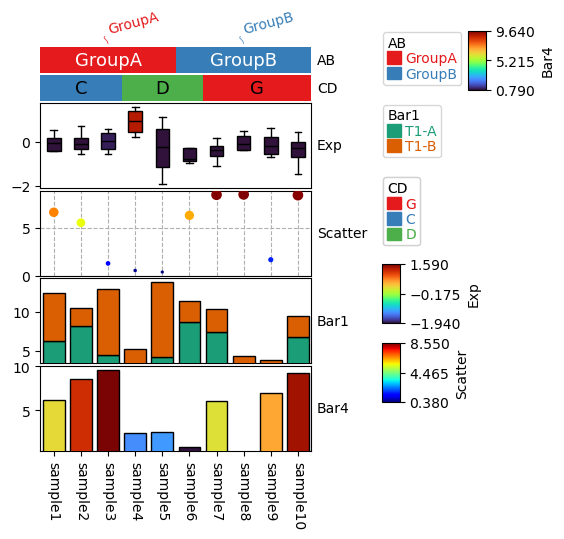

In [19]:
df_box = pd.DataFrame(np.random.randn(10, 4), columns=['Gene' + str(i) for i in range(1, 5)])
df_box.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['TMB1', 'TMB2'])
df_bar.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_scatter = pd.DataFrame(np.random.uniform(0, 10, 10), columns=['Scatter'])
df_scatter.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar1 = pd.DataFrame(np.random.uniform(0, 10, (10, 2)), columns=['T1-A', 'T1-B'])
df_bar1.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar4 = pd.DataFrame(np.random.uniform(0, 10, (10, 1)), columns=['T4'])
df_bar4.index = ['sample' + str(i) for i in range(1, df_box.shape[0] + 1)]
df_bar4.iloc[7,0]=np.nan

plt.figure(figsize=(3.5, 5))
col_ha = pch.HeatmapAnnotation(
    label=pch.anno_label(df.AB, merge=True,rotation=15),
    AB=pch.anno_simple(df.AB,add_text=True,legend=True),
#     axis=1,
    CD=pch.anno_simple(df.CD, add_text=True,legend=True,text_kws={'color':'black'}),
    Exp=pch.anno_boxplot(df_box, cmap='turbo',legend=True),
    Scatter=pch.anno_scatterplot(df_scatter,grid=True),
    Bar1=pch.anno_barplot(df_bar1,legend=True,cmap='Dark2'),
    Bar4=pch.anno_barplot(df_bar4,legend=True,cmap='turbo'),
    plot=True,
    legend=True,
    legend_gap=5,
    hgap=0.5
)
col_ha.show_ticklabels(df.index.tolist(),fontdict={'color':'black'},rotation=-90)
plt.show()

In [4]:
df = pd.DataFrame(['GroupA'] * 5 + ['GroupB'] * 5, columns=['AB'])
df['CD'] = ['C'] * 3 + ['D'] * 3 + ['G'] * 4
df['EF'] = ['E'] * 6 + ['F'] * 2 + ['H'] * 2
df['F'] = np.random.normal(0, 1, 10)
df.index = ['sample' + str(i) for i in range(1, df.shape[0] + 1)]
df.head()

,AB,CD,EF,F
sample1,GroupA,C,E,1.288422
sample2,GroupA,C,E,0.152439
sample3,GroupA,C,E,0.163203
sample4,GroupA,D,E,-0.341759
sample5,GroupA,D,E,0.810193


Starting plotting HeatmapAnnotations


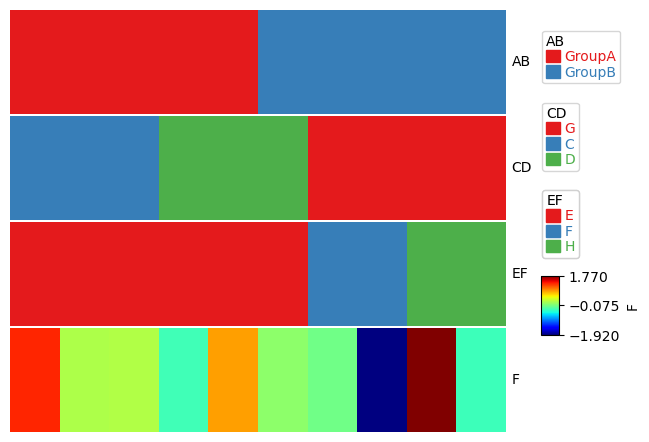

In [6]:
# plt.figure(figsize=(3, 4))
col_ha = pch.HeatmapAnnotation(df=df,plot=True,legend=True,legend_gap=5,hgap=0.5,axis=1)
plt.show()

In [72]:
df

,1-1-lh,1-1-rh,5-1-lh,5-1-rh,6-1-lh,6-1-rh,6-2-lh,6-2-rh,7-1-lh,7-1-rh,...,13-2-rh,13-3-rh,13-4-rh,17-1-lh,17-1-rh,17-2-lh,17-2-rh,17-3-lh,17-3-rh,17-4-lh
0,56.055744,92.031036,-35.898861,-1.889181,5.898688,-43.692322,-47.664265,12.284122,1.566538,-13.042585,...,14.738475,-16.853010,-34.217819,-21.734550,1.028253,7.791784,68.903725,-10.520872,120.490463,-39.686432
1,55.547253,43.690075,19.568010,15.902983,-23.231823,-10.745867,10.269546,31.275831,-26.309488,-18.077026,...,23.792282,8.927007,-19.732401,-13.035799,46.381824,-15.752450,31.000332,-39.607521,24.764011,-36.771008
2,60.997768,63.438793,19.247454,37.209419,2.392153,16.509109,-5.314236,2.372976,-7.342168,-24.550989,...,8.968520,1.413584,-4.955075,26.033442,34.212200,1.326110,-22.580757,12.985169,-75.027451,6.434262
3,18.514868,12.657158,32.896915,11.199619,-14.665752,2.073715,32.634335,45.825409,-47.632999,-6.580215,...,19.627728,49.208748,1.661293,55.297466,4.255006,-2.420144,12.098393,-15.819172,-37.361431,-4.650954
4,-2.527392,-63.104668,18.396759,3.219077,-41.856911,-24.690414,-33.975418,-24.149668,-6.315651,-29.344135,...,55.853088,46.737320,4.586625,43.067562,52.219875,28.232882,-11.719750,5.453649,5.169828,87.809135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,-7.429513,-4.813219,0.017912,-25.305094,-75.461159,-70.289261,-13.119029,-5.194376,-56.022263,-24.290606,...,-19.436220,15.894722,22.195951,76.179489,51.934669,-6.614513,-6.690762,22.893030,48.274380,76.228455
916,-33.554138,-38.605621,-32.935612,-21.783203,-16.198238,-34.893780,16.504656,13.005379,26.230785,4.764211,...,16.711153,17.339653,13.682954,50.962399,13.696922,63.503616,57.401176,24.974548,51.972153,64.538788
917,-78.539566,-74.197189,-32.800556,-37.021500,2.098941,-18.581594,11.386637,3.676295,52.871113,-3.970096,...,45.261150,37.007389,29.753304,43.800747,8.144480,47.281460,70.499649,66.994400,81.539246,64.969772
918,-103.235825,-98.744286,-14.330512,-17.224781,-3.007454,-42.672840,1.581095,-38.023777,37.736561,4.872248,...,33.483253,37.434860,-14.403917,46.674419,40.954796,0.877180,37.577152,20.517746,3.124434,56.718388


In [74]:
data

level_1,1-1-lh,1-1-rh,12-1-lh,12-1-rh,12-2-lh,12-2-rh,12-3-lh,13-1-lh,13-1-rh,13-2-lh,...,7-2-lh,7-2-rh,7-3-lh,7-3-rh,8-1-lh,8-1-rh,8-2-lh,8-2-rh,8-3-lh,8-3-rh
level_0,,,,,,,,,,,,,,,,,,,,,
1-1-lh,1.000000,0.881516,-0.049793,0.026902,-0.144335,-0.141253,0.119250,-0.261589,-0.272701,-0.370021,...,-0.366065,-0.325680,-0.196770,-0.144566,-0.366818,-0.388756,-0.352529,-0.363982,-0.341524,-0.350452
1-1-rh,0.881516,1.000000,-0.112697,-0.036909,-0.144277,-0.189683,0.084633,-0.324230,-0.332886,-0.374322,...,-0.361036,-0.274151,-0.142392,-0.070452,-0.358625,-0.402173,-0.302286,-0.339989,-0.315931,-0.343379
12-1-lh,-0.049793,-0.112697,1.000000,0.343464,0.470239,0.100802,0.438449,0.339667,0.089811,0.272394,...,-0.036493,-0.171179,-0.043298,-0.158039,0.005598,-0.060007,0.079078,-0.040060,0.027878,-0.075781
12-1-rh,0.026902,-0.036909,0.343464,1.000000,0.130549,0.278569,0.127621,-0.014404,0.051249,-0.090130,...,-0.170053,-0.124278,-0.112148,-0.063705,-0.172007,-0.040629,-0.079687,0.024864,-0.092263,-0.068858
12-2-lh,-0.144335,-0.144277,0.470239,0.130549,1.000000,0.521377,0.506652,0.320966,0.141884,0.608392,...,-0.075986,-0.095015,0.012966,-0.082816,0.023340,0.058718,0.034181,0.033355,-0.022982,0.025638
12-2-rh,-0.141253,-0.189683,0.100802,0.278569,0.521377,1.000000,0.278552,0.089660,0.226261,0.309138,...,-0.104747,-0.030334,-0.018104,-0.039992,-0.008107,0.160223,-0.030453,0.094641,-0.120722,0.038884
12-3-lh,0.119250,0.084633,0.438449,0.127621,0.506652,0.278552,1.000000,0.129512,0.014521,0.308019,...,-0.090940,-0.116309,0.011849,-0.105306,-0.120627,-0.049796,-0.033058,-0.090530,-0.175381,-0.065856
13-1-lh,-0.261589,-0.324230,0.339667,-0.014404,0.320966,0.089660,0.129512,1.000000,0.609404,0.579235,...,-0.079010,-0.126067,-0.173809,-0.239998,0.324253,0.246041,0.133757,0.125637,0.131368,0.079011
13-1-rh,-0.272701,-0.332886,0.089811,0.051249,0.141884,0.226261,0.014521,0.609404,1.000000,0.439514,...,-0.129445,-0.093015,-0.167026,-0.204851,0.278182,0.384119,0.112151,0.230240,0.106365,0.140664


In [80]:
test = data.iloc[:, :2]
test['level_0'] = test.index.to_list()
test['level_1'] = test.columns[0]
test.columns = ['value', 'level_0', 'level_1']
test.index = np.arange(test.shape[0])
test

/tmp/43821.tmpdir/ipykernel_852/2375840142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['level_0'] = test.index.to_list()
/tmp/43821.tmpdir/ipykernel_852/2375840142.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['level_1'] = test.columns[0]


,value,level_0,level_1
0,1.000000,1-1-lh,1-1-lh
1,0.881516,1-1-rh,1-1-lh
2,-0.049793,12-1-lh,1-1-lh
3,0.026902,12-1-rh,1-1-lh
4,-0.144335,12-2-lh,1-1-lh
5,-0.141253,12-2-rh,1-1-lh
6,0.119250,12-3-lh,1-1-lh
7,-0.261589,13-1-lh,1-1-lh
8,-0.272701,13-1-rh,1-1-lh
9,-0.370021,13-2-lh,1-1-lh


In [73]:
corr_mat

,level_0,level_1,correlation,Level
0,1-1-lh,1-1-lh,1.000000,High
1,1-1-lh,1-1-rh,0.881516,High
2,1-1-lh,5-1-lh,0.431619,Middle
3,1-1-lh,5-1-rh,0.418708,Middle
4,1-1-lh,6-1-lh,-0.084634,Low
...,...,...,...,...
1439,17-4-lh,17-2-lh,0.517481,Middle
1440,17-4-lh,17-2-rh,0.256544,Low
1441,17-4-lh,17-3-lh,0.264381,Low
1442,17-4-lh,17-3-rh,0.090302,Low


In [67]:
import seaborn as sns

# Load the brain networks dataset, select subset, and collapse the multi-index
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)
used_networks = [1, 5, 6, 7, 8, 12, 13, 17]
used_columns = (df.columns
                  .get_level_values("network")
                  .astype(int)
                  .isin(used_networks))
df = df.loc[:, used_columns]

df.columns = df.columns.map("-".join)



# Compute a correlation matrix and convert to long-form
corr_mat = df.corr().stack().reset_index(name="correlation")
corr_mat['Level']=corr_mat.correlation.apply(lambda x:'High' if x>=0.7 else 'Middle' if x >= 0.3 else 'Low')
data=corr_mat.pivot(index='level_0',columns='level_1',values='correlation')

In [68]:
corr_mat.Level.value_counts().index.tolist()

['Low', 'Middle', 'High']

In [69]:
corr_mat.head()

,level_0,level_1,correlation,Level
0,1-1-lh,1-1-lh,1.000000,High
1,1-1-lh,1-1-rh,0.881516,High
2,1-1-lh,5-1-lh,0.431619,Middle
3,1-1-lh,5-1-rh,0.418708,Middle
4,1-1-lh,6-1-lh,-0.084634,Low


/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:379: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:395: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-self.smin)/delta)
/home/estorrs/.local/lib/

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 134.56110253285124
Plotting legends..
Estimated legend width: 14.465277777777779 mm


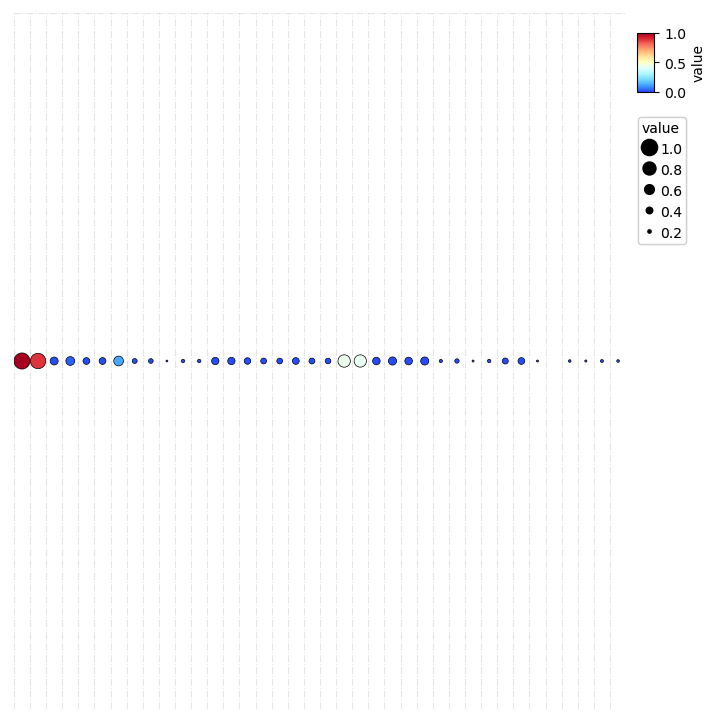

In [84]:
plt.figure(figsize=(8,8))
cm = pch.DotClustermapPlotter(test,x='level_0',y='level_1',value='value',
                          s='value',cmap='RedYellowBlue_r',c='value',
                          vmax=1,vmin=0,
                          linewidth=0.5,edgecolor='black', row_cluster=False, col_cluster=False)
plt.show()

/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:360: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data2d = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:379: FutureWarning: The provided callable <function mean at 0x7f418c16e7a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.kwargs["s"] = data.pivot_table(
/home/estorrs/.local/lib/python3.11/site-packages/PyComplexHeatmap/dotHeatmap.py:395: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  self.kwargs["s"]=self.kwargs["s"].applymap(lambda x:(x-self.smin)/delta)
/home/estorrs/.local/lib/

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 132.808800071564
Plotting legends..
Estimated legend width: 28.22361111111111 mm


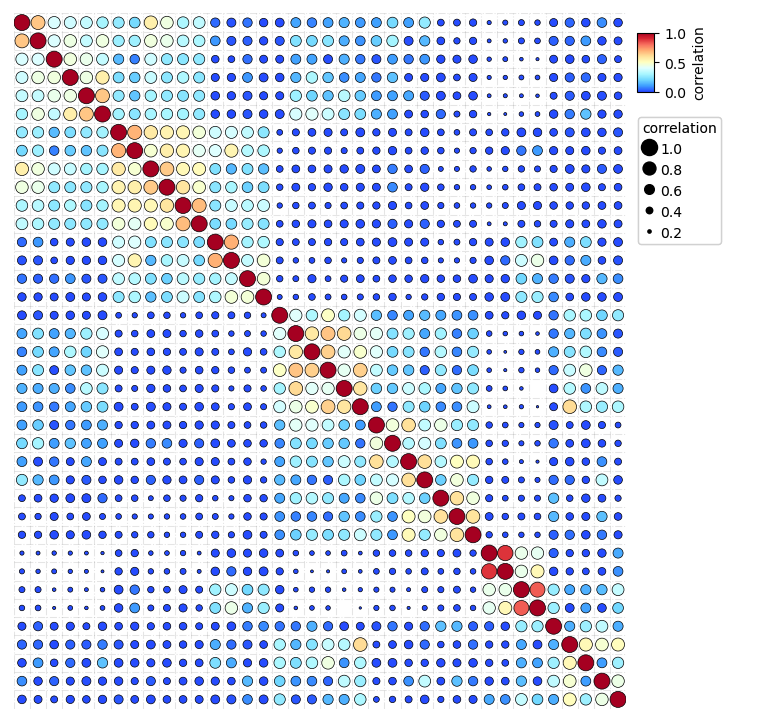

In [71]:
plt.figure(figsize=(8,8))
cm = pch.DotClustermapPlotter(corr_mat,x='level_0',y='level_1',value='correlation',
                          s='correlation',cmap='RedYellowBlue_r',c='correlation',
                          vmax=1,vmin=0,
                          linewidth=0.5,edgecolor='black')
plt.show()